In [1]:
import os
import geopandas as gpd
print(os.getcwd())

d:\ENSAE Paris\3A\S1\ML_Climate_risk\PROJET\ML_For_Climate_risk\ML-for-Climate-Risk\Reconnaissance_Catnat\Indicateur_secheresse


In [2]:
import pandas as pd

df_test = pd.read_csv("../../data/df_test_reconnaissance.csv", sep=",")
# 3 niveaux .. pour sortir : Indicateur_secheresse → Reconnaissance_Catnat → ML-for-Climate-Risk → data


In [3]:
df_test.head()

,N° Insee,Nom de la commune,event_period,Decision_text,recognized,Dernier_lag_decision,n_events,nbr_demandes_passees,nbr_demandes_passees_acceptées,avg_duration_days,...,years_all_communes_recognized_before,argile_niveau,swi_unif_min,x,y,year,lag_decision,mean_past_duration,p_raw,p_corr
0,71190,EPINAC,2023-01-01,Non reconnue,0,Reconnue,4,3,1.195882,313.0,...,0.0,-1.391782,0.809245,816100.694851,6655456.60,2023,1.497270,0.635058,0.345826,0.345826
1,71194,FARGES LES CHALON,2023-01-01,Non reconnue,0,Non reconnue,7,6,1.195882,364.0,...,0.0,-1.391782,0.809245,837776.124805,6638600.20,2023,-0.667867,0.396710,0.317676,0.317676
2,71202,FONTAINES,2023-01-01,Non reconnue,0,Reconnue,7,6,3.112193,364.0,...,0.0,-1.391782,0.809245,835213.869092,6640489.40,2023,1.497270,-0.049531,0.273973,0.273973
3,71204,FRAGNES LA LOYERE,2023-01-01,Non reconnue,0,Reconnue,5,4,2.154038,364.0,...,0.0,-1.391782,0.809245,839668.290005,6639506.30,2023,1.497270,0.272239,0.309008,0.309008
4,71206,LA FRETTE,2023-01-01,Non reconnue,0,Reconnue,3,2,1.195882,364.0,...,0.0,-1.391782,0.809245,857041.204419,6617638.95,2023,1.497270,-0.057475,0.355300,0.355300


In [4]:
df_test.columns.tolist()

['N° Insee',
 'Nom de la commune',
 'event_period',
 'Decision_text',
 'recognized',
 'Dernier_lag_decision',
 'n_events',
 'nbr_demandes_passees',
 'nbr_demandes_passees_acceptées',
 'avg_duration_days',
 'first_date_debut',
 'last_date_fin',
 'Code_peril',
 'Departement',
 'NB_DEP',
 'dep_recog_last5',
 'Catnat_intensity_dep',
 'accept_rate_dep',
 'dep_ever_recog',
 'dep_delay_median',
 'total_dep_requests',
 'years_all_communes_recognized_before',
 'argile_niveau',
 'swi_unif_min',
 'x',
 'y',
 'year',
 'lag_decision',
 'mean_past_duration',
 'p_raw',
 'p_corr']

In [8]:
LimitAdmin = r"D:\ENSAE Paris\3A\S1\ML_Climate_risk\Nouveau dossier\Bases\ADE_4-0_GPKG_LAMB93_FXX-ED2025-10-15.gpkg"
#gdf_regions = gpd.read_file(LimitAdmin, layer="region").to_crs(2154)
gdf_commune = gpd.read_file(LimitAdmin, layer="commune").to_crs(2154)

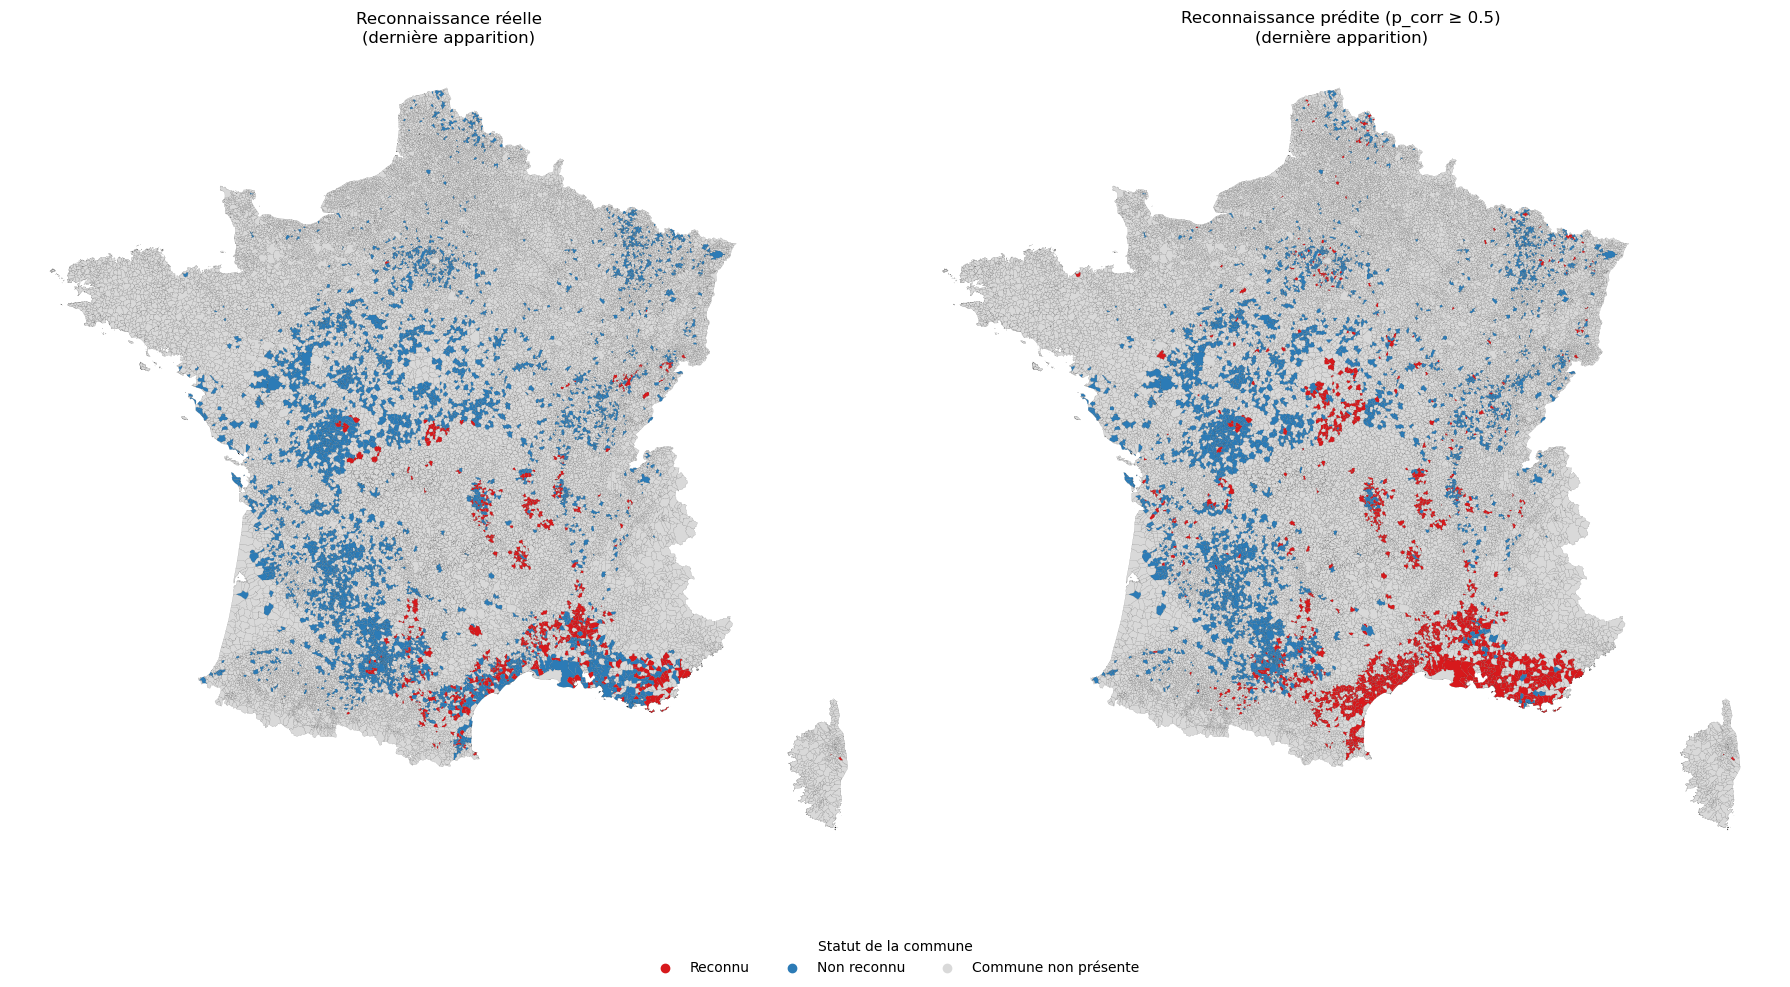

Réel :
recognized_real_cat
Commune non présente    30451
Non reconnu              3671
Reconnu                   624
Name: count, dtype: int64

Prédit :
recognized_pred_cat
Commune non présente    30451
Non reconnu              2922
Reconnu                  1373
Name: count, dtype: int64


In [ ]:
# ============================================================
# CARTE NATIONALE – DERNIÈRE APPARITION PAR COMMUNE
# Comparaison sur une ligne : Réel (gauche) vs Prédit (droite)
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Préparation des données
# ------------------------------------------------------------
df = df_test.copy()
# Harmoniser le nom du code INSEE
df = df.rename(columns={"N° Insee": "code_insee"})

# Dernière apparition (année max) par commune
df_last = (
    df.sort_values("year")
      .groupby("code_insee", as_index=False)
      .tail(1)
      .copy()
)

# Variable prédite binaire
df_last["recognized_pred"] = (df_last["p_corr"] >= 0.5).astype(int)

# ------------------------------------------------------------
# 2) Jointure avec la géométrie communale complète
# ------------------------------------------------------------

# gdf_commune doit contenir : code_insee, geometry
gdf = gdf_commune.merge(
    df_last[["code_insee", "recognized", "recognized_pred"]],
    on="code_insee",
    how="left"
)

# ------------------------------------------------------------
# 3) Catégories cartographiques
# ------------------------------------------------------------

def classify(val):
    if pd.isna(val):
        return "Commune non présente"
    elif val == 1:
        return "Reconnu"
    else:
        return "Non reconnu"

gdf["recognized_real_cat"] = gdf["recognized"].apply(classify)
gdf["recognized_pred_cat"] = gdf["recognized_pred"].apply(classify)

# ------------------------------------------------------------
# 4) Palette de couleurs
# ------------------------------------------------------------

COLOR_MAP = {
    "Reconnu": "#d7191c",              # rouge
    "Non reconnu": "#2c7bb6",          # bleu
    "Commune non présente": "#d9d9d9"  # gris clair
}

# ------------------------------------------------------------
# 5) FIGURE UNIQUE — 1 LIGNE, 2 COLONNES
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# ----- Carte gauche : Réel -----
gdf.plot(
    ax=axes[0],
    color=gdf["recognized_real_cat"].map(COLOR_MAP),
    linewidth=0.05,
    edgecolor="black"
)

axes[0].set_title("Reconnaissance réelle\n(dernière apparition)")
axes[0].axis("off")

# ----- Carte droite : Prédit -----
gdf.plot(
    ax=axes[1],
    color=gdf["recognized_pred_cat"].map(COLOR_MAP),
    linewidth=0.05,
    edgecolor="black"
)

axes[1].set_title("Reconnaissance prédite (p_corr ≥ 0.5)\n(dernière apparition)")
axes[1].axis("off")

# ------------------------------------------------------------
# 6) Légende commune
# ------------------------------------------------------------

for label, color in COLOR_MAP.items():
    axes[1].scatter([], [], color=color, label=label)

fig.legend(
    title="Statut de la commune",
    loc="lower center",
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ------------------------------------------------------------
# 7) Vérifications rapides
# ------------------------------------------------------------

print("Réel :")
print(gdf["recognized_real_cat"].value_counts(dropna=False))

print("\nPrédit :")
print(gdf["recognized_pred_cat"].value_counts(dropna=False))


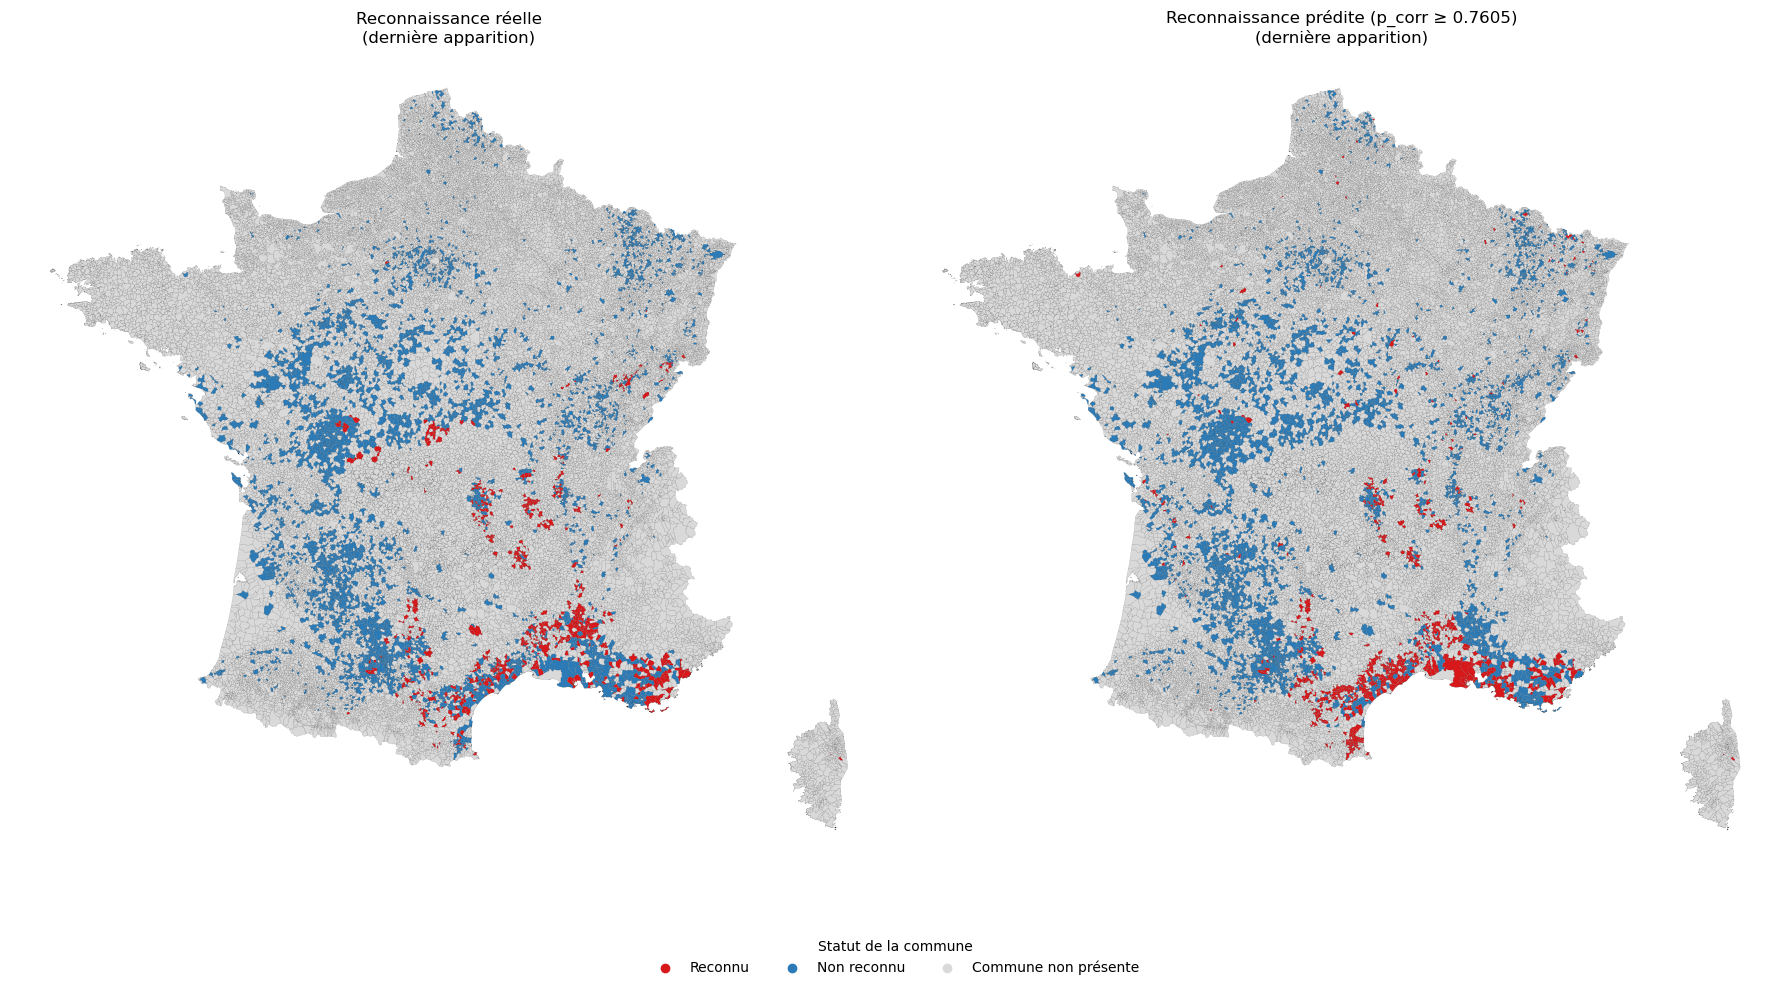

Réel :
recognized_real_cat
Commune non présente    30451
Non reconnu              3671
Reconnu                   624
Name: count, dtype: int64

Prédit :
recognized_pred_cat
Commune non présente    30451
Non reconnu              3588
Reconnu                   707
Name: count, dtype: int64


In [25]:
# ============================================================
# CARTE NATIONALE – DERNIÈRE APPARITION PAR COMMUNE
# Comparaison sur une ligne : Réel (gauche) vs Prédit (droite)
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Préparation des données
# ------------------------------------------------------------

# Harmoniser le nom du code INSEE
df = df.rename(columns={"N° Insee": "code_insee"})

# Dernière apparition (année max) par commune
df_last = (
    df.sort_values("year")
      .groupby("code_insee", as_index=False)
      .tail(1)
      .copy()
)

# Variable prédite binaire
df_last["recognized_pred"] = (df_last["p_corr"] >= 0.7605).astype(int)

# ------------------------------------------------------------
# 2) Jointure avec la géométrie communale complète
# ------------------------------------------------------------

# gdf_commune doit contenir : code_insee, geometry
gdf = gdf_commune.merge(
    df_last[["code_insee", "recognized", "recognized_pred"]],
    on="code_insee",
    how="left"
)

# ------------------------------------------------------------
# 3) Catégories cartographiques
# ------------------------------------------------------------

def classify(val):
    if pd.isna(val):
        return "Commune non présente"
    elif val == 1:
        return "Reconnu"
    else:
        return "Non reconnu"

gdf["recognized_real_cat"] = gdf["recognized"].apply(classify)
gdf["recognized_pred_cat"] = gdf["recognized_pred"].apply(classify)

# ------------------------------------------------------------
# 4) Palette de couleurs
# ------------------------------------------------------------

COLOR_MAP = {
    "Reconnu": "#d7191c",              # rouge
    "Non reconnu": "#2c7bb6",          # bleu
    "Commune non présente": "#d9d9d9"  # gris clair
}

# ------------------------------------------------------------
# 5) FIGURE UNIQUE — 1 LIGNE, 2 COLONNES
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# ----- Carte gauche : Réel -----
gdf.plot(
    ax=axes[0],
    color=gdf["recognized_real_cat"].map(COLOR_MAP),
    linewidth=0.05,
    edgecolor="black"
)

axes[0].set_title("Reconnaissance réelle\n(dernière apparition)")
axes[0].axis("off")

# ----- Carte droite : Prédit -----
gdf.plot(
    ax=axes[1],
    color=gdf["recognized_pred_cat"].map(COLOR_MAP),
    linewidth=0.05,
    edgecolor="black"
)

axes[1].set_title("Reconnaissance prédite (p_corr ≥ 0.7605)\n(dernière apparition)")
axes[1].axis("off")

# ------------------------------------------------------------
# 6) Légende commune
# ------------------------------------------------------------

for label, color in COLOR_MAP.items():
    axes[1].scatter([], [], color=color, label=label)

fig.legend(
    title="Statut de la commune",
    loc="lower center",
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ------------------------------------------------------------
# 7) Vérifications rapides
# ------------------------------------------------------------

print("Réel :")
print(gdf["recognized_real_cat"].value_counts(dropna=False))

print("\nPrédit :")
print(gdf["recognized_pred_cat"].value_counts(dropna=False))


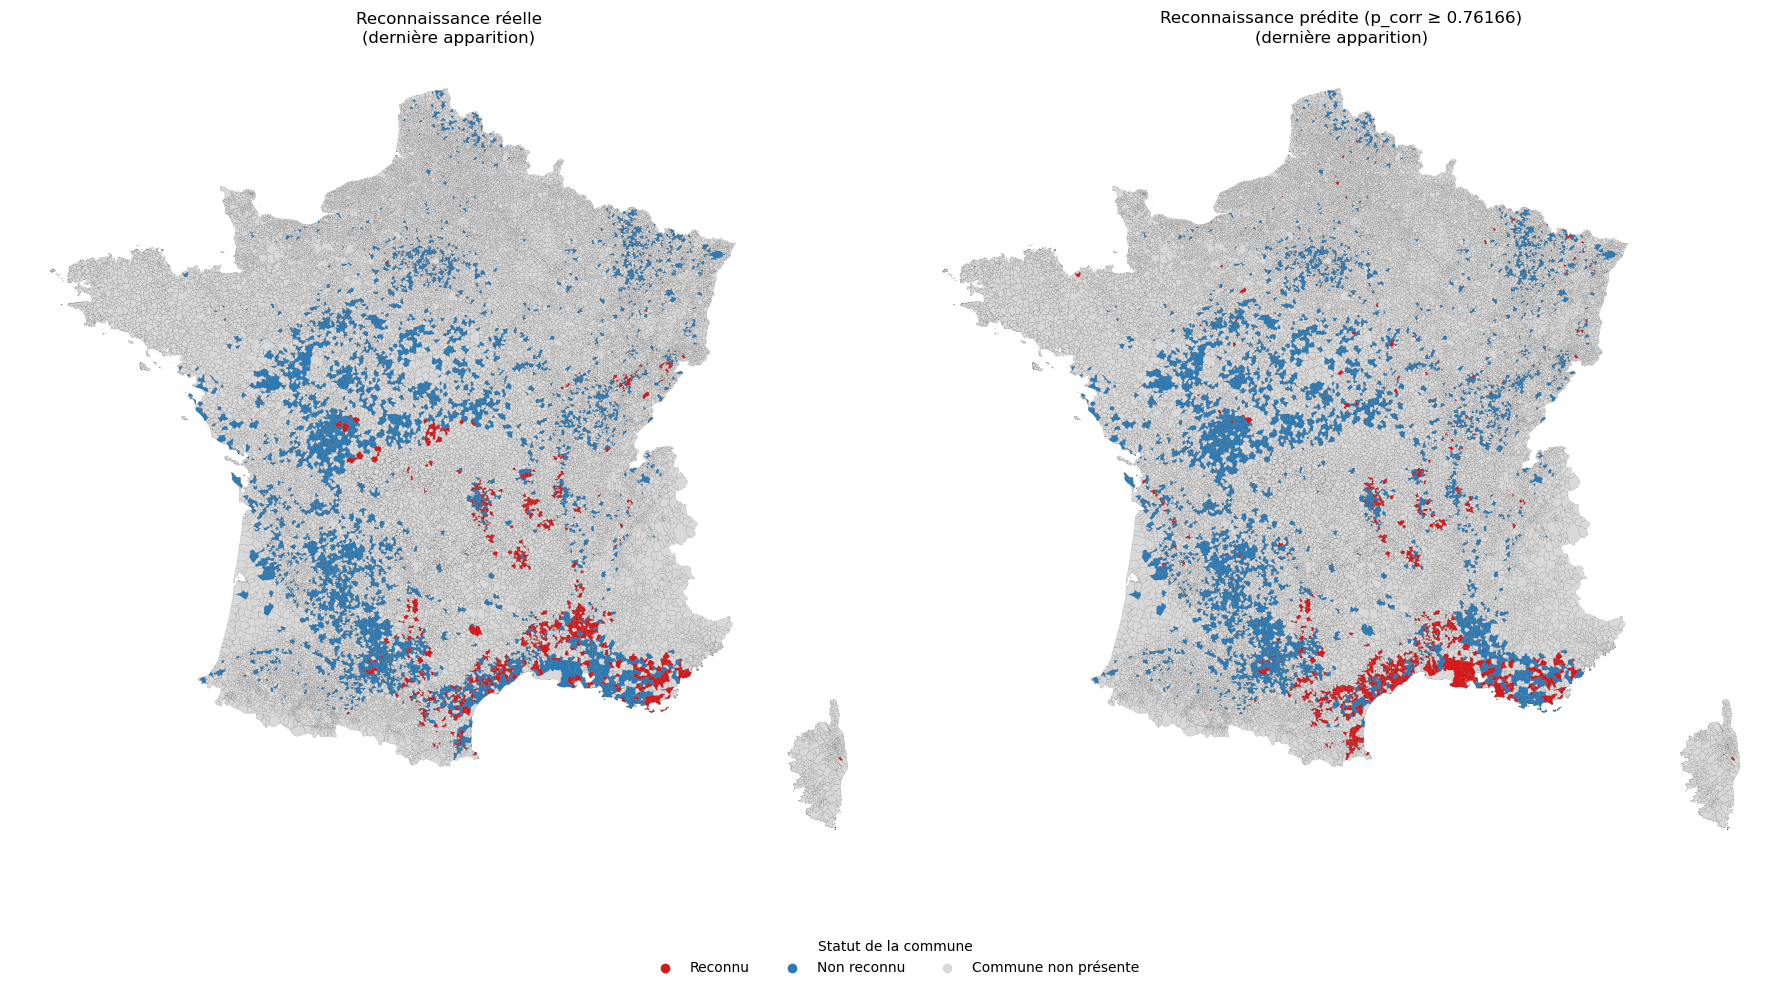

Réel :
recognized_real_cat
Commune non présente    30451
Non reconnu              3671
Reconnu                   624
Name: count, dtype: int64

Prédit :
recognized_pred_cat
Commune non présente    30451
Non reconnu              3593
Reconnu                   702
Name: count, dtype: int64


In [26]:
# ============================================================
# CARTE NATIONALE – DERNIÈRE APPARITION PAR COMMUNE
# Comparaison sur une ligne : Réel (gauche) vs Prédit (droite)
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Préparation des données
# ------------------------------------------------------------

# Harmoniser le nom du code INSEE
df = df.rename(columns={"N° Insee": "code_insee"})

# Dernière apparition (année max) par commune
df_last = (
    df.sort_values("year")
      .groupby("code_insee", as_index=False)
      .tail(1)
      .copy()
)

# Variable prédite binaire
df_last["recognized_pred"] = (df_last["p_corr"] >= 0.76166).astype(int)

# ------------------------------------------------------------
# 2) Jointure avec la géométrie communale complète
# ------------------------------------------------------------

# gdf_commune doit contenir : code_insee, geometry
gdf = gdf_commune.merge(
    df_last[["code_insee", "recognized", "recognized_pred"]],
    on="code_insee",
    how="left"
)

# ------------------------------------------------------------
# 3) Catégories cartographiques
# ------------------------------------------------------------

def classify(val):
    if pd.isna(val):
        return "Commune non présente"
    elif val == 1:
        return "Reconnu"
    else:
        return "Non reconnu"

gdf["recognized_real_cat"] = gdf["recognized"].apply(classify)
gdf["recognized_pred_cat"] = gdf["recognized_pred"].apply(classify)

# ------------------------------------------------------------
# 4) Palette de couleurs
# ------------------------------------------------------------

COLOR_MAP = {
    "Reconnu": "#d7191c",              # rouge
    "Non reconnu": "#2c7bb6",          # bleu
    "Commune non présente": "#d9d9d9"  # gris clair
}

# ------------------------------------------------------------
# 5) FIGURE UNIQUE — 1 LIGNE, 2 COLONNES
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# ----- Carte gauche : Réel -----
gdf.plot(
    ax=axes[0],
    color=gdf["recognized_real_cat"].map(COLOR_MAP),
    linewidth=0.05,
    edgecolor="black"
)

axes[0].set_title("Reconnaissance réelle\n(dernière apparition)")
axes[0].axis("off")

# ----- Carte droite : Prédit -----
gdf.plot(
    ax=axes[1],
    color=gdf["recognized_pred_cat"].map(COLOR_MAP),
    linewidth=0.05,
    edgecolor="black"
)

axes[1].set_title("Reconnaissance prédite (p_corr ≥ 0.76166)\n(dernière apparition)")
axes[1].axis("off")

# ------------------------------------------------------------
# 6) Légende commune
# ------------------------------------------------------------

for label, color in COLOR_MAP.items():
    axes[1].scatter([], [], color=color, label=label)

fig.legend(
    title="Statut de la commune",
    loc="lower center",
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ------------------------------------------------------------
# 7) Vérifications rapides
# ------------------------------------------------------------

print("Réel :")
print(gdf["recognized_real_cat"].value_counts(dropna=False))

print("\nPrédit :")
print(gdf["recognized_pred_cat"].value_counts(dropna=False))
